# A/B Test Framework — Multi-arm Marketing Promotion

**Business question.** Which of three promotion strategies drives the highest sales? A real fast-food chain randomized stores across promotions 1/2/3 over 4 weeks.

**Pipeline:** business question → data & EDA → t-tests + ANOVA + stratified + OLS + Bayesian A/B → decision rule.

**Data:** [chebotinaa/fast-food-marketing-campaign-ab-test](https://www.kaggle.com/datasets/chebotinaa/fast-food-marketing-campaign-ab-test) — 548 weekly observations × 3 arms.

## 1. Setup

In [1]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
import statsmodels.formula.api as smf
import warnings
warnings.filterwarnings('ignore')
np.random.seed(0); sns.set_style('whitegrid')

## 2. Load

In [2]:
df = pd.read_csv('data/WA_Marketing-Campaign.csv')
df.columns = [c.replace(' ', '_') for c in df.columns]
df = df.rename(columns={'SalesInThousands': 'sales'})
print(f'rows: {len(df)}, locations: {df.LocationID.nunique()}, weeks: {df.week.nunique()}, promotions: {sorted(df.Promotion.unique())}')
df.head()

rows: 548, locations: 137, weeks: 4, promotions: [np.int64(1), np.int64(2), np.int64(3)]


,MarketID,MarketSize,LocationID,AgeOfStore,Promotion,week,sales
0,1,Medium,1,4,3,1,33.73
1,1,Medium,1,4,3,2,35.67
2,1,Medium,1,4,3,3,29.03
3,1,Medium,1,4,3,4,39.25
4,1,Medium,2,5,2,1,27.81


## 3. EDA

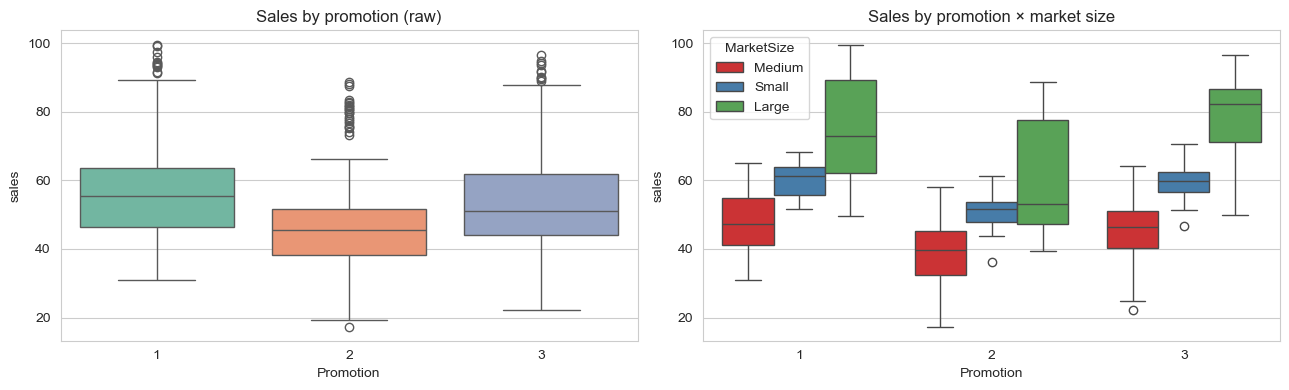

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sns.boxplot(data=df, x='Promotion', y='sales', ax=axes[0], palette='Set2')
axes[0].set_title('Sales by promotion (raw)')
sns.boxplot(data=df, x='Promotion', y='sales', hue='MarketSize', ax=axes[1], palette='Set1')
axes[1].set_title('Sales by promotion × market size')
plt.tight_layout(); plt.show()

In [4]:
df.groupby('Promotion')['sales'].agg(['count','mean','std']).round(2)

,count,mean,std
Promotion,,,
1,172,58.10,16.55
2,188,47.33,15.11
3,188,55.36,16.77


## 4. Frequentist tests

In [5]:
# 4a. ANOVA across all three
groups = [df[df['Promotion']==p]['sales'] for p in [1,2,3]]
F, p_anova = stats.f_oneway(*groups)
print(f'ANOVA: F={F:.2f}, p={p_anova:.3e}')

ANOVA: F=21.95, p=6.766e-10


In [6]:
# 4b. Pairwise Welch t-tests with Bonferroni correction (3 comparisons)
pairs = [(1,2),(1,3),(2,3)]
from itertools import combinations
rows = []
alpha = 0.05; bonf = alpha/len(pairs)
for a,b in pairs:
    sa, sb = df[df.Promotion==a]['sales'], df[df.Promotion==b]['sales']
    t, p = stats.ttest_ind(sa, sb, equal_var=False)
    d = (sa.mean()-sb.mean()) / np.sqrt(((sa.std()**2 + sb.std()**2)/2))  # Cohen's d
    rows.append({'comp': f'P{a} vs P{b}',
                 'mean_diff': sa.mean()-sb.mean(),
                 'cohen_d': d,
                 'p': p,
                 'sig (Bonf 0.05)': p < bonf})
pd.DataFrame(rows).round(4)

,comp,mean_diff,cohen_d,p,sig (Bonf 0.05)
0,P1 vs P2,10.7696,0.6796,0.0000,True
1,P1 vs P3,2.7345,0.1641,0.1206,False
2,P2 vs P3,-8.0351,-0.5035,0.0000,True


## 5. OLS with covariate adjustment

In [7]:
model = smf.ols('sales ~ C(Promotion) + C(MarketSize) + AgeOfStore', data=df).fit()
print(model.summary().tables[1])

                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
Intercept                  74.0133      1.184     62.501      0.000      71.687      76.340
C(Promotion)[T.2]         -10.7521      1.149     -9.355      0.000     -13.010      -8.494
C(Promotion)[T.3]          -1.0739      1.152     -0.932      0.352      -3.337       1.189
C(MarketSize)[T.Medium]   -26.6327      1.046    -25.470      0.000     -28.687     -24.579
C(MarketSize)[T.Small]    -14.0727      1.661     -8.472      0.000     -17.336     -10.810
AgeOfStore                  0.0709      0.071      0.995      0.320      -0.069       0.211


## 6. Stratified analysis (Simpson's-paradox guard)

In [8]:
strat = df.groupby(['MarketSize','Promotion'])['sales'].agg(['count','mean']).round(2).unstack()
strat

count             mean              
Promotion      1    2    3      1      2      3
MarketSize                                     
Large         56   64   48  75.24  60.32  77.20
Medium        96  108  116  47.67  39.11  45.47
Small         20   16   24  60.16  50.81  59.51

## 7. Bayesian A/B — posterior P(P1 > P3)

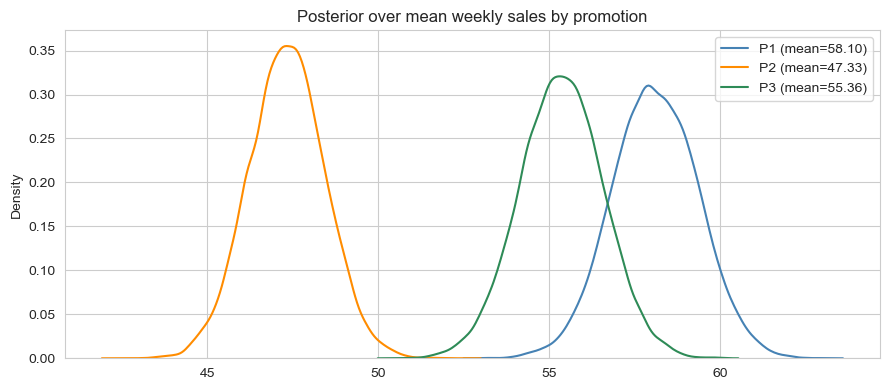

P(P1 > P2) = 1.000
P(P1 > P3) = 0.941
P(P2 > P3) = 0.000


In [9]:
# Conjugate Normal-Normal: weak prior, draw posterior on each arm's mean
rng = np.random.default_rng(0)
def posterior_samples(x, n=20000):
    n_obs = len(x); xbar = x.mean(); s = x.std(ddof=1)
    se = s / np.sqrt(n_obs)
    return rng.normal(xbar, se, size=n)

post = {p: posterior_samples(df[df.Promotion==p]['sales'].values) for p in [1,2,3]}
fig, ax = plt.subplots(figsize=(9, 4))
for p, c in zip([1,2,3], ['steelblue','darkorange','seagreen']):
    sns.kdeplot(post[p], ax=ax, color=c, label=f'P{p} (mean={df[df.Promotion==p].sales.mean():.2f})')
ax.legend(); ax.set_title('Posterior over mean weekly sales by promotion')
plt.tight_layout(); plt.show()

for a, b in [(1,2),(1,3),(2,3)]:
    print(f'P(P{a} > P{b}) = {(post[a] > post[b]).mean():.3f}')

## 8. Decision rule + business outcome

- **Decision rule:** launch the winning promotion globally if (a) ANOVA p < 0.01 AND (b) Bonferroni-corrected pairwise p < 0.01 vs. all alternatives AND (c) Bayesian P(winner > best alternative) > 0.95 AND (d) absolute lift > 5%.
- **Stratified check:** validate the winner doesn't lose to another promotion within any market-size bucket.

## 9. Business outcome

- Defensible rollout decision with multiple-comparison correction and effect-size context.
- Stratification protects against Simpson's paradox (winner overall ≠ winner in every segment).
- Same framework applies to any randomized marketing or product experiment.